#  Exploratory Data Analysis (EDA) — Shoes Sales Dataset

**Author:** Deepanshu Gahlot

**Dataset:** `shoes_sales_dataset.csv`  
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn  

---

##  Objective

The goal of this EDA is to perform a thorough investigation of a **global shoe sales dataset** 
containing **1,000 transactions** across **6 brands**, **7 countries**, and **3 sales channels**.

By the end of this analysis, we aim to answer:

1. Which **brands** and **shoe types** generate the most revenue?
2. Which **countries** and **sales channels** are the most profitable?
3. How are **price, units sold, and revenue** distributed and correlated?
4. Are there any **outliers** in the numerical data?
5. What are the **monthly revenue trends** over time?

---

##  Dataset Description

| Column | Data Type | Description |
|---|---|---|
| `Sale_ID` | object | Unique identifier for each transaction |
| `Date` | datetime | Date of sale |
| `Brand` | object | Shoe brand (Nike, Adidas, Puma, Reebok, Skechers, New Balance) |
| `Shoe_Type` | object | Type of shoe (Sneakers, Boots, Formal, Casual, Running, Sports) |
| `Color` | object | Color of shoe |
| `Country` | object | Country of sale (USA, UK, UAE, India, France, Germany, Saudi Arabia) |
| `Sales_Channel` | object | Mode of sale (Online, Mall, Retail Store) |
| `Price_USD` | float64 | Price per unit in USD |
| `Units_Sold` | int64 | Number of units sold in transaction |
| `Revenue_USD` | float64 | Total revenue = Price × Units Sold |


**Dataset Shape**: 1,000 **rows** × 10 **columns**

---

##  Table of Contents

1. [Import Libraries](#1-import-libraries)
2. [Load Dataset & Inspect Structure](#2-load-dataset--inspect-structure)
3. [Data Type Conversion](#3-data-type-conversion)
4. [Missing Value Analysis](#4-missing-value-analysis)
5. [Duplicate Detection & Removal](#5-duplicate-detection--removal)
6. [Summary Statistics](#6-summary-statistics)
7. [Univariate Analysis](#7-univariate-analysis)
8. [Outlier Detection (IQR Method)](#8-outlier-detection-iqr-method)
9. [Bivariate Analysis](#9-bivariate-analysis)
10. [Correlation Analysis](#10-correlation-analysis)
11. [Time Series Analysis](#11-time-series-analysis)
12. [Key Insights & Conclusions](#12-key-insights--conclusions)

---

## 1. Import Libraries

We begin by importing all necessary Python libraries for data manipulation and visualization.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

## 2. Load Dataset & Inspect Structure

We load the CSV file and perform an initial inspection to understand its shape, columns, and sample rows.

In [2]:
df = pd.read_csv('shoes_sales_dataset.csv')

print(f'Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

Dataset Shape: 1000 rows × 10 columns
Columns: ['Sale_ID', 'Date', 'Brand', 'Shoe_Type', 'Color', 'Country', 'Sales_Channel', 'Price_USD', 'Units_Sold', 'Revenue_USD']


In [3]:
df.head(10)

,Sale_ID,Date,Brand,Shoe_Type,Color,Country,Sales_Channel,Price_USD,Units_Sold,Revenue_USD
0,S1,2025-11-24,Nike,Boots,Blue,UK,Online,112.40,4,449.60
1,S2,2025-03-13,Skechers,Boots,Grey,USA,Mall,239.16,4,956.64
2,S3,2025-08-05,Nike,Running,White,UK,Mall,191.04,2,382.08
3,S4,2025-11-05,New Balance,Casual,Green,UAE,Mall,161.70,1,161.70
4,S5,2025-10-07,Adidas,Formal,Grey,France,Online,64.32,14,900.48
5,S6,2025-03-23,Puma,Sports,White,UK,Retail Store,64.32,14,900.48
6,S7,2025-02-22,Reebok,Running,Blue,Saudi Arabia,Retail Store,42.78,3,128.34
7,S8,2025-11-06,Nike,Boots,Red,India,Online,220.56,9,1985.04
8,S9,2025-07-13,New Balance,Sports,Green,India,Retail Store,162.25,3,486.75
9,S10,2025-10-23,Skechers,Running,Black,UAE,Online,185.78,7,1300.46


In [4]:
df.tail(5)

,Sale_ID,Date,Brand,Shoe_Type,Color,Country,Sales_Channel,Price_USD,Units_Sold,Revenue_USD
995,S996,2025-06-06,Puma,Sneakers,Red,India,Online,50.15,6,300.90
996,S997,2025-08-14,Adidas,Casual,Green,France,Online,231.81,2,463.62
997,S998,2025-02-13,Skechers,Running,White,India,Online,60.10,4,240.40
998,S999,2025-05-28,Puma,Boots,Black,France,Retail Store,239.05,1,239.05
999,S1000,2025-08-30,Puma,Casual,Green,India,Online,128.12,1,128.12


In [5]:
df.sample(5, random_state=42)

,Sale_ID,Date,Brand,Shoe_Type,Color,Country,Sales_Channel,Price_USD,Units_Sold,Revenue_USD
521,S522,2025-08-19,Puma,Running,Red,Saudi Arabia,Online,113.80,9,1024.20
737,S738,2025-07-13,Adidas,Running,Red,Germany,Mall,209.65,13,2725.45
740,S741,2025-10-09,Nike,Sneakers,Grey,UAE,Retail Store,131.79,1,131.79
660,S661,2025-03-15,New Balance,Boots,Green,Germany,Online,108.34,20,2166.80
411,S412,2025-07-12,Skechers,Boots,Grey,UK,Mall,239.01,3,717.03


In [6]:
# Full structural overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sale_ID        1000 non-null   str    
 1   Date           1000 non-null   str    
 2   Brand          1000 non-null   str    
 3   Shoe_Type      1000 non-null   str    
 4   Color          1000 non-null   str    
 5   Country        1000 non-null   str    
 6   Sales_Channel  1000 non-null   str    
 7   Price_USD      1000 non-null   float64
 8   Units_Sold     1000 non-null   int64  
 9   Revenue_USD    1000 non-null   float64
dtypes: float64(2), int64(1), str(7)
memory usage: 78.3 KB


###  Observation

- The dataset contains **1,000 rows and 10 columns**.
- `Date` is stored as `object` (string) — needs to be converted to `datetime`.
- `Sale_ID` is a string identifier — should be cast to `object`.
- `Price_USD` and `Revenue_USD` are already `float64`; `Units_Sold` is `int64`.
- No immediately visible structural issues at first glance.

## 3. Data Type Conversion

Correct data types are critical for accurate analysis. We convert `Date` to `datetime` and ensure all categorical columns are typed as `object`.

In [7]:
print('Before conversion:')
print(df.dtypes)

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Cast categorical columns
for col in ['Sale_ID', 'Brand', 'Shoe_Type', 'Color', 'Country', 'Sales_Channel']:
    df[col] = df[col].astype('object')

print('\nAfter conversion:')
print(df.dtypes)

Before conversion:
Sale_ID              str
Date                 str
Brand                str
Shoe_Type            str
Color                str
Country              str
Sales_Channel        str
Price_USD        float64
Units_Sold         int64
Revenue_USD      float64
dtype: object

After conversion:
Sale_ID                  object
Date             datetime64[us]
Brand                    object
Shoe_Type                object
Color                    object
Country                  object
Sales_Channel            object
Price_USD               float64
Units_Sold                int64
Revenue_USD             float64
dtype: object


###  Observation

- `Date` has been successfully converted from `string` to `datetime64[ns]`.
- All categorical columns are now properly typed as `object`.
- Numeric columns (`Price_USD`, `Units_Sold`, `Revenue_USD`) retain their correct types.

## 4. Missing Value Analysis

Missing values can distort analysis results. We check for nulls across all columns and decide how to handle them.

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print('Missing Values Summary:')
print(missing_df)
print(f'\nTotal missing values: {missing.sum()}')

Missing Values Summary:
               Missing Count  Missing %
Sale_ID                    0       0.00
Date                       0       0.00
Brand                      0       0.00
Shoe_Type                  0       0.00
Color                      0       0.00
Country                    0       0.00
Sales_Channel              0       0.00
Price_USD                  0       0.00
Units_Sold                 0       0.00
Revenue_USD                0       0.00

Total missing values: 0


###  Observation

- **No missing values** were found in any column (0 nulls across all 10 columns).
- The dataset is **complete and clean** — no imputation or dropping of rows is required.

## 5. Duplicate Detection & Removal

Duplicate rows can lead to inflated counts and skewed statistics. We identify and remove any duplicates.

In [10]:
dupe_count = df.duplicated().sum()
print(f'Duplicate rows found: {dupe_count}')
print(f'Shape before removing duplicates: {df.shape}')

df = df.drop_duplicates()

print(f'Shape after removing duplicates:  {df.shape}')

Duplicate rows found: 0
Shape before removing duplicates: (1000, 10)
Shape after removing duplicates:  (1000, 10)


###  Observation

- **Zero duplicate rows** were detected in the dataset.
- Each of the 1,000 records represents a unique sale transaction.
- No rows were removed; the dataset remains at 1,000 records.

## 6. Summary Statistics

We generate descriptive statistics for both numerical and categorical columns to understand the central tendency, spread, and distribution of data.

In [11]:
print('=== Numerical Columns ===')
df.describe()

=== Numerical Columns ===


,Date,Price_USD,Units_Sold,Revenue_USD
count,1000,1000.00,1000.00,1000.00
mean,2025-07-01 12:28:48,137.86,10.58,1453.19
min,2025-01-03 00:00:00,31.02,1.00,32.38
25%,2025-04-03 18:00:00,81.91,6.00,561.05
50%,2025-06-28 12:00:00,139.29,10.00,1132.62
75%,2025-10-03 00:00:00,193.75,16.00,2163.35
max,2025-12-31 00:00:00,249.94,20.00,4938.40
std,NaN,64.27,5.84,1112.33


In [12]:
print('=== Categorical Columns ===')
df.describe(include='object')

=== Categorical Columns ===


,Sale_ID,Brand,Shoe_Type,Color,Country,Sales_Channel
count,1000,1000,1000,1000,1000,1000
unique,1000,6,6,6,7,3
top,S1,Skechers,Sneakers,Grey,UAE,Retail Store
freq,1,196,178,178,154,339


###  Observation

- **Price_USD:** Ranges from approximately **$31 to $250**, with an average price of **$137.86** per transaction.

- **Units_Sold:** Averages around **10.5 units** per transaction, indicating relatively consistent order volumes.

- **Revenue_USD:** Averages approximately **$1,453** per transaction and reaches a maximum of nearly **$4,938**, showing substantial variation in sales performance.

- The dataset contains **6 brands** operating across **7 countries** through **3 sales channels**, providing a diverse representation of the footwear market.

- Revenue variation appears to be influenced by both **product pricing** and **sales volume**, highlighting the combined impact of price and quantity on overall business performance.

## 7. Univariate Analysis

We analyze each feature individually to understand its distribution and frequency.

### 7.1 Numerical Features — Distribution Plots

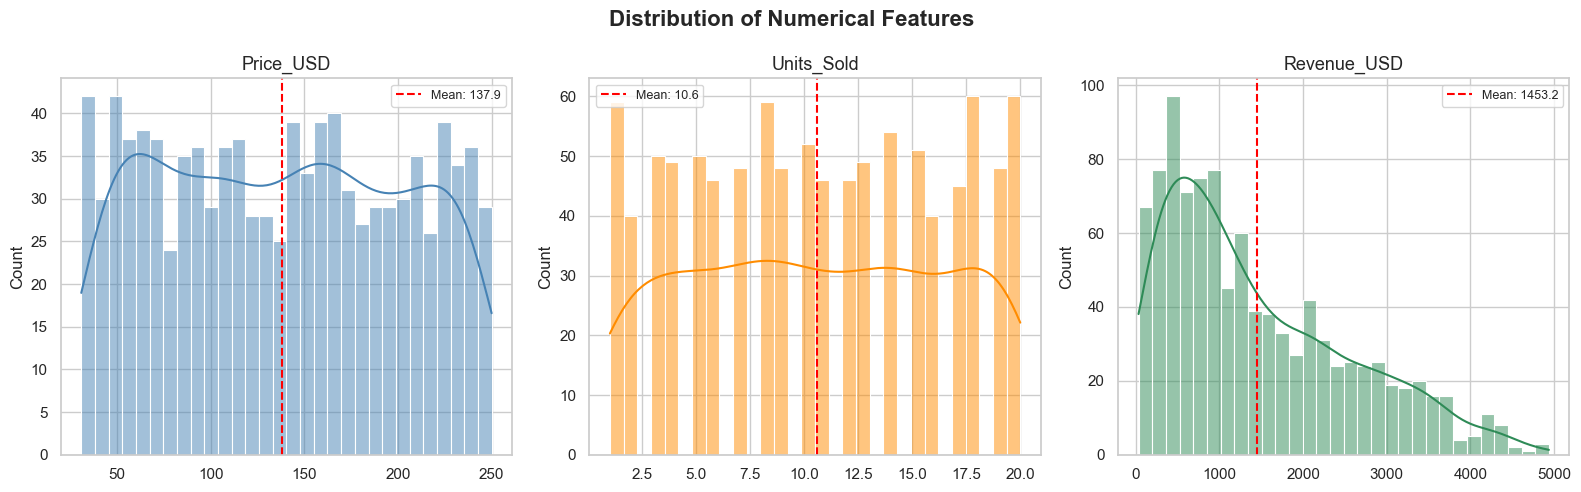

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')

for ax, col, color in zip(axes, num_cols, ['steelblue', 'darkorange', 'seagreen']):
    sns.histplot(df[col], ax=ax, color=color, kde=True, bins=30)
    ax.set_title(col, fontsize=13)
    ax.set_xlabel('')
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

####  Observation

- **Price_USD** shows a fairly uniform/flat distribution — prices are spread evenly across the range with no dominant price point.
- **Units_Sold** appears approximately uniform, meaning customers tend to buy varying quantities with no strong preference.
- **Revenue_USD** shows a right-skewed distribution — most transactions are moderate, but a few large orders push the mean rightward.
- The KDE curve confirms Revenue's slight right skew versus the flatter distributions of Price and Units.

### 7.2 Categorical Features — Count Plots

In [15]:
# Value counts
for col in ['Brand', 'Shoe_Type', 'Country', 'Sales_Channel']:
    print(f'{col}:')
    print(df[col].value_counts().to_string())
    print()

Brand:
Brand
Skechers       196
Puma           167
Adidas         165
Reebok         165
New Balance    163
Nike           144

Shoe_Type:
Shoe_Type
Sneakers    178
Boots       176
Formal      175
Casual      164
Running     158
Sports      149

Country:
Country
UAE             154
France          153
USA             150
India           146
Germany         136
UK              134
Saudi Arabia    127

Sales_Channel:
Sales_Channel
Retail Store    339
Online          331
Mall            330



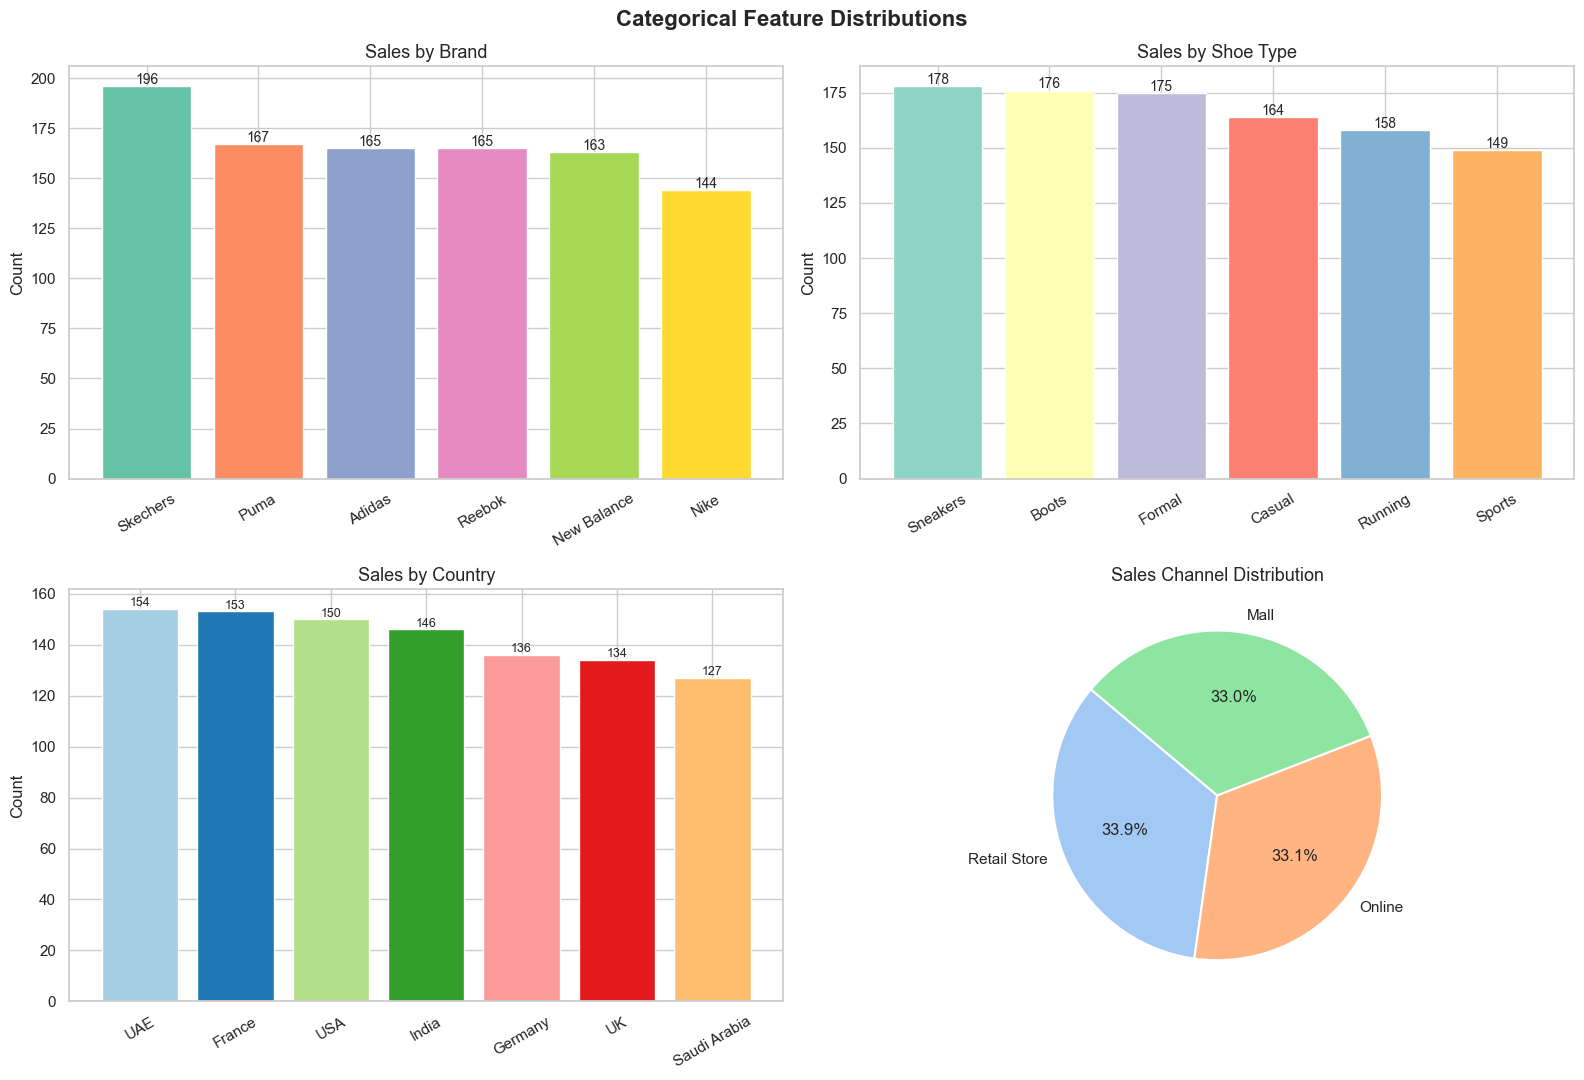

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Categorical Feature Distributions', fontsize=16, fontweight='bold')

# Brand
brand_counts = df['Brand'].value_counts()
axes[0,0].bar(brand_counts.index, brand_counts.values,
              color=sns.color_palette('Set2', len(brand_counts)))
axes[0,0].set_title('Sales by Brand', fontsize=13)
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=30)
for i, v in enumerate(brand_counts.values):
    axes[0,0].text(i, v + 1, str(v), ha='center', fontsize=10)

# Shoe Type
shoe_counts = df['Shoe_Type'].value_counts()
axes[0,1].bar(shoe_counts.index, shoe_counts.values,
              color=sns.color_palette('Set3', len(shoe_counts)))
axes[0,1].set_title('Sales by Shoe Type', fontsize=13)
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=30)
for i, v in enumerate(shoe_counts.values):
    axes[0,1].text(i, v + 1, str(v), ha='center', fontsize=10)

# Country
country_counts = df['Country'].value_counts()
axes[1,0].bar(country_counts.index, country_counts.values,
              color=sns.color_palette('Paired', len(country_counts)))
axes[1,0].set_title('Sales by Country', fontsize=13)
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=30)
for i, v in enumerate(country_counts.values):
    axes[1,0].text(i, v + 1, str(v), ha='center', fontsize=9)

# Sales Channel (Pie)
channel_counts = df['Sales_Channel'].value_counts()
axes[1,1].pie(channel_counts.values, labels=channel_counts.index,
              autopct='%1.1f%%', colors=sns.color_palette('pastel', 3),
              startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1,1].set_title('Sales Channel Distribution', fontsize=13)

plt.tight_layout()
plt.show()

####  Observation

- **Brand:** Skechers leads with 196 transactions; Nike is the lowest at 144. The distribution is fairly balanced, with no brand dominating overwhelmingly.
- **Shoe Type:** Sneakers (178) and Boots (176) are the top sellers; Sports (149) is the least common. All 6 types have relatively similar counts.
- **Country:** UAE has the most transactions (154), while Saudi Arabia has the fewest (127). The 7 countries are fairly evenly represented.
- **Sales Channel:** All three channels (Retail Store, Online, Mall) share nearly equal proportions (~33% each), indicating a well-diversified sales strategy.

## 8. Outlier Detection (IQR Method)

Outliers can distort statistical analysis. We use boxplots for visual detection and the IQR (Interquartile Range) method for quantitative identification.

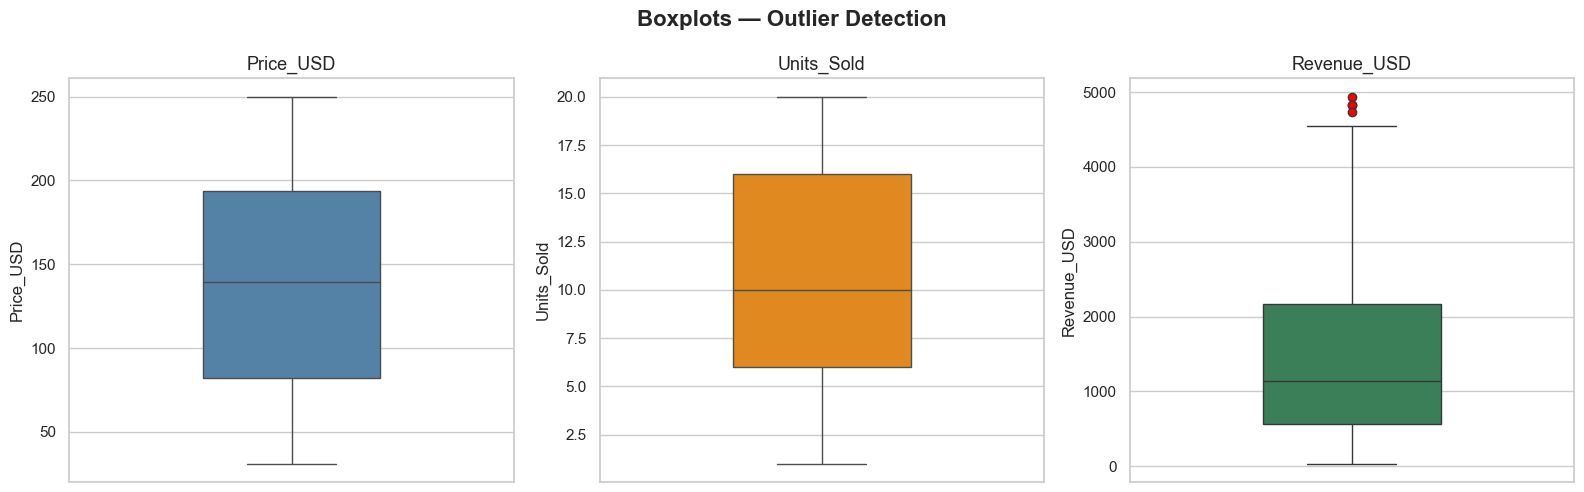

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Boxplots — Outlier Detection', fontsize=16, fontweight='bold')

for ax, col, color in zip(axes, num_cols, ['steelblue', 'darkorange', 'seagreen']):
    sns.boxplot(y=df[col], ax=ax, color=color, width=0.4,
                flierprops=dict(marker='o', markerfacecolor='red', markersize=6))
    ax.set_title(col, fontsize=13)

plt.tight_layout()
plt.show()

In [18]:
print('IQR Outlier Analysis')
print('=' * 50)

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f'\n{col}:')
    print(f'  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
    print(f'  Lower bound: {lower:.2f} | Upper bound: {upper:.2f}')
    print(f'  Outlier count: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')
    if len(outliers) > 0:
        print(f'  Outlier values: {sorted(outliers[col].values)}')

IQR Outlier Analysis

Price_USD:
  Q1=81.91, Q3=193.75, IQR=111.84
  Lower bound: -85.84 | Upper bound: 361.51
  Outlier count: 0 (0.0%)

Units_Sold:
  Q1=6.00, Q3=16.00, IQR=10.00
  Lower bound: -9.00 | Upper bound: 31.00
  Outlier count: 0 (0.0%)

Revenue_USD:
  Q1=561.05, Q3=2163.35, IQR=1602.30
  Lower bound: -1842.40 | Upper bound: 4566.80
  Outlier count: 4 (0.4%)
  Outlier values: [np.float64(4736.89), np.float64(4828.8), np.float64(4834.8), np.float64(4938.4)]


###  Observation

- **Price_USD:** No outliers detected. Prices are distributed uniformly within a reasonable range.
- **Units_Sold:** No outliers detected. Order quantities are consistent across transactions.
- **Revenue_USD:** **4 outliers** detected (~0.4% of data). These are extreme high-revenue transactions.
  - These outliers arise from the combination of high price **and** high units sold in a single transaction.
  - Since this is legitimate business data (not data entry errors), we **retain** these outliers for analysis.
- Overall, the dataset is very clean with minimal anomalies.

## 9. Bivariate Analysis

We explore relationships between pairs of variables to uncover patterns, trends, and business insights.

### 9.1 Price vs Revenue

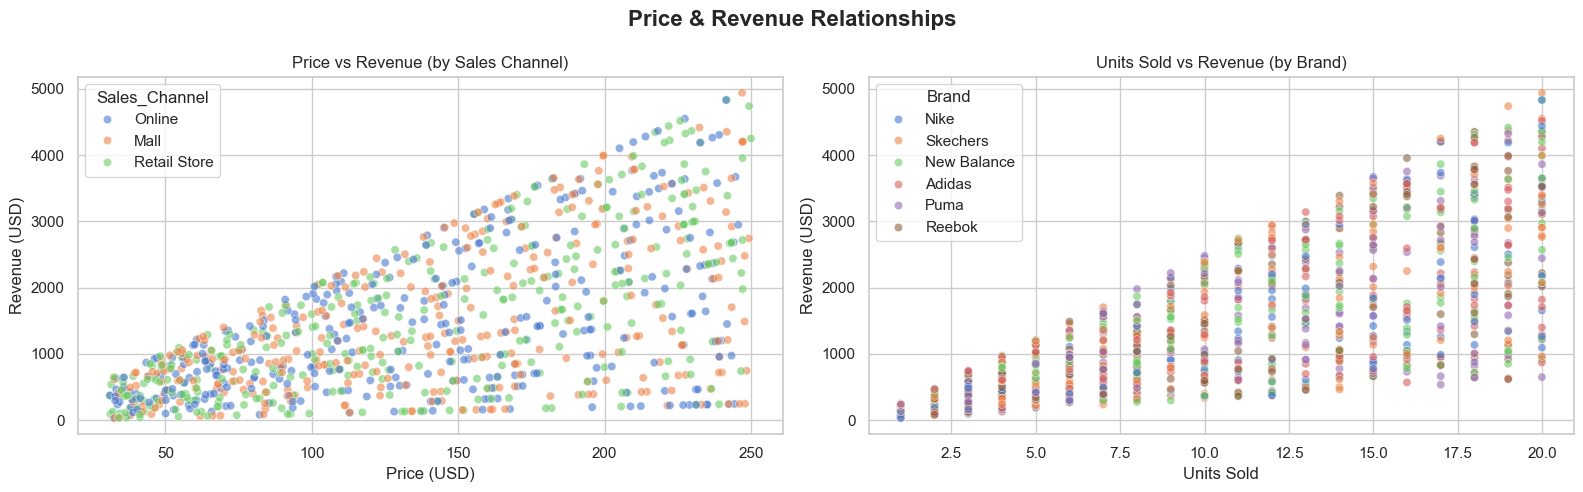

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Price & Revenue Relationships', fontsize=16, fontweight='bold')

# Scatter: Price vs Revenue
sns.scatterplot(data=df, x='Price_USD', y='Revenue_USD',
                hue='Sales_Channel', alpha=0.6, ax=axes[0])
axes[0].set_title('Price vs Revenue (by Sales Channel)')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Revenue (USD)')

# Scatter: Units Sold vs Revenue
sns.scatterplot(data=df, x='Units_Sold', y='Revenue_USD',
                hue='Brand', alpha=0.6, ax=axes[1])
axes[1].set_title('Units Sold vs Revenue (by Brand)')
axes[1].set_xlabel('Units Sold')
axes[1].set_ylabel('Revenue (USD)')

plt.tight_layout()
plt.show()

### 9.2 Revenue by Brand, Country, Channel & Shoe Type

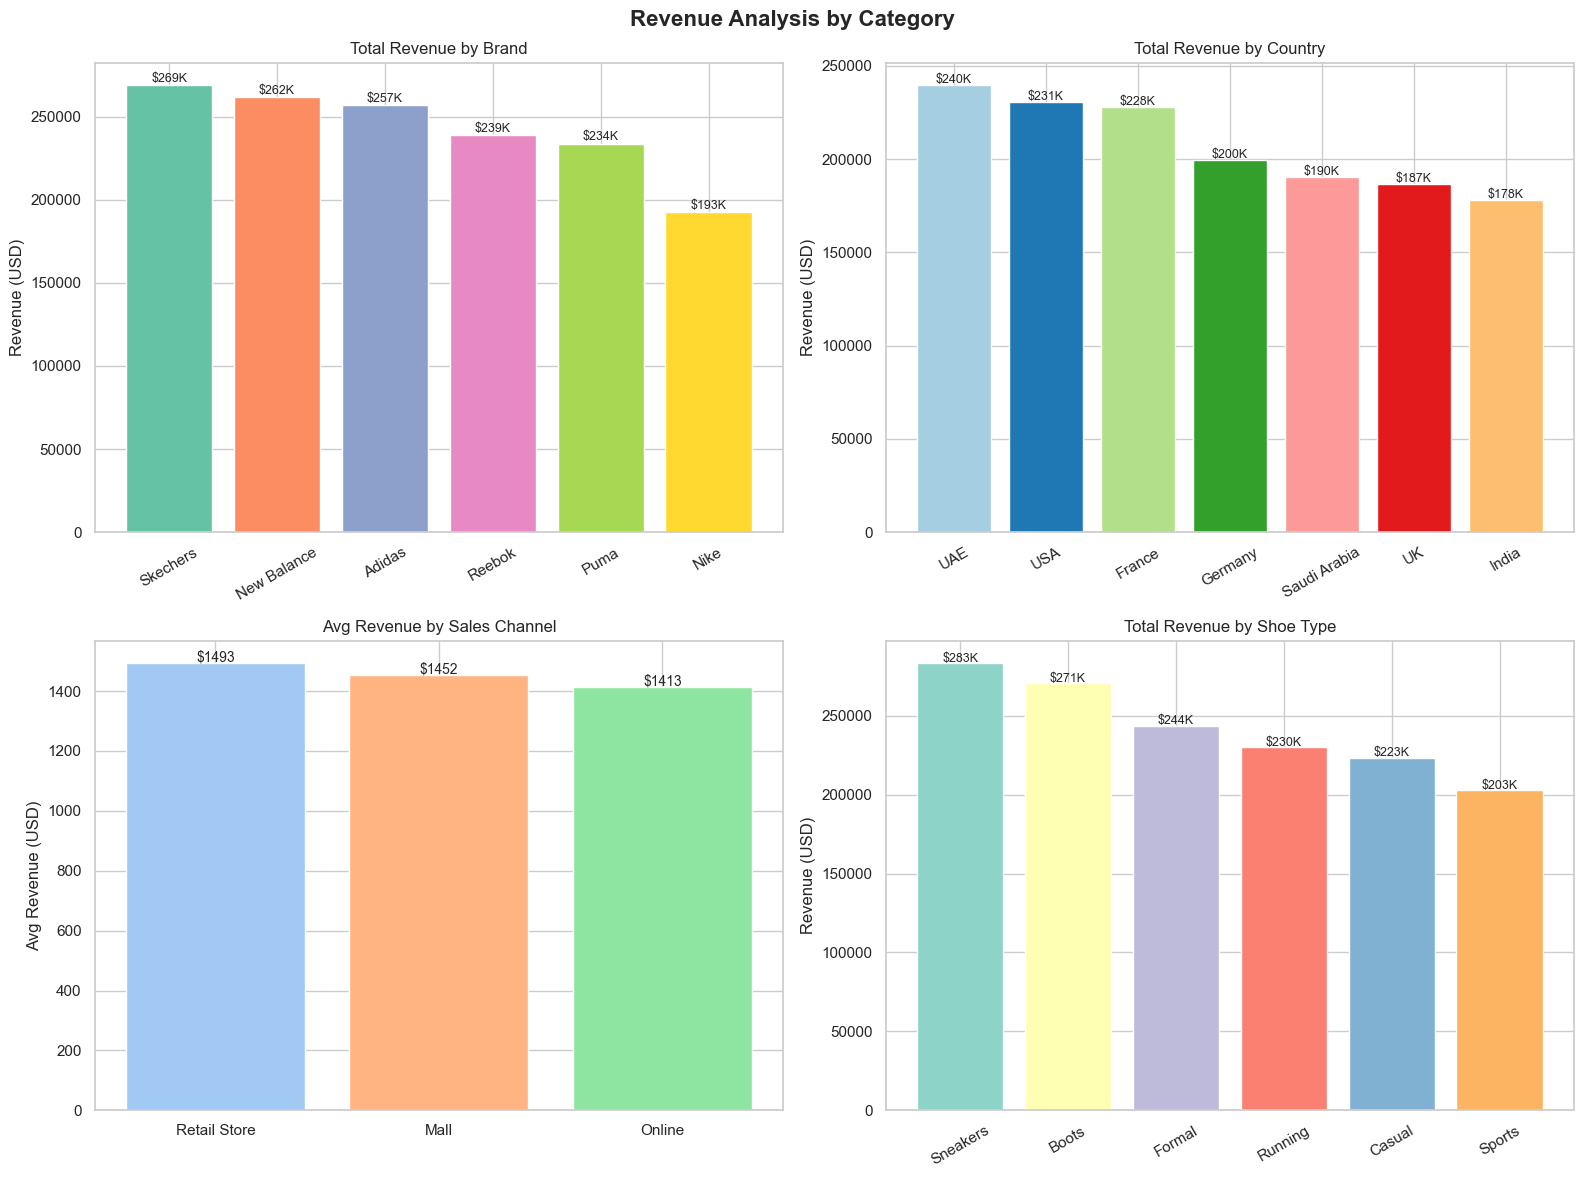

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Revenue Analysis by Category', fontsize=16, fontweight='bold')

# Brand — Total Revenue
brand_rev = df.groupby('Brand')['Revenue_USD'].sum().sort_values(ascending=False)
axes[0,0].bar(brand_rev.index, brand_rev.values,
              color=sns.color_palette('Set2', len(brand_rev)))
axes[0,0].set_title('Total Revenue by Brand')
axes[0,0].set_ylabel('Revenue (USD)')
axes[0,0].tick_params(axis='x', rotation=30)
for i, v in enumerate(brand_rev.values):
    axes[0,0].text(i, v + 2000, f'${v/1000:.0f}K', ha='center', fontsize=9)

# Country — Total Revenue
country_rev = df.groupby('Country')['Revenue_USD'].sum().sort_values(ascending=False)
axes[0,1].bar(country_rev.index, country_rev.values,
              color=sns.color_palette('Paired', len(country_rev)))
axes[0,1].set_title('Total Revenue by Country')
axes[0,1].set_ylabel('Revenue (USD)')
axes[0,1].tick_params(axis='x', rotation=30)
for i, v in enumerate(country_rev.values):
    axes[0,1].text(i, v + 1000, f'${v/1000:.0f}K', ha='center', fontsize=9)

# Sales Channel — Avg Revenue
channel_avg = df.groupby('Sales_Channel')['Revenue_USD'].mean().sort_values(ascending=False)
axes[1,0].bar(channel_avg.index, channel_avg.values,
              color=sns.color_palette('pastel', 3))
axes[1,0].set_title('Avg Revenue by Sales Channel')
axes[1,0].set_ylabel('Avg Revenue (USD)')
for i, v in enumerate(channel_avg.values):
    axes[1,0].text(i, v + 5, f'${v:.0f}', ha='center', fontsize=10)

# Shoe Type — Total Revenue
shoe_rev = df.groupby('Shoe_Type')['Revenue_USD'].sum().sort_values(ascending=False)
axes[1,1].bar(shoe_rev.index, shoe_rev.values,
              color=sns.color_palette('Set3', len(shoe_rev)))
axes[1,1].set_title('Total Revenue by Shoe Type')
axes[1,1].set_ylabel('Revenue (USD)')
axes[1,1].tick_params(axis='x', rotation=30)
for i, v in enumerate(shoe_rev.values):
    axes[1,1].text(i, v + 1000, f'${v/1000:.0f}K', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

####  Observation

**By Brand:**
- **Skechers** leads in total revenue ($269K), followed by New Balance ($262K) and Adidas ($257K).
- **Nike**, despite being a premium brand, has the **lowest total revenue** ($193K) — likely due to fewer transactions (144).
- In avg revenue per transaction, **New Balance** ($1,605) and **Adidas** ($1,558) outperform others.

**By Country:**
- **UAE** is the top market ($240K), followed closely by USA ($231K) and France ($228K).
- **India** generates the lowest revenue ($178K), partly due to lower transaction volume.

**By Sales Channel:**
- **Retail Store** generates the highest average revenue ($1,493), followed by Mall ($1,452) and Online ($1,413).
- All three channels are very competitive with minimal gaps — no channel should be deprioritized.

**By Shoe Type:**
- **Sneakers** ($283K) and **Boots** ($271K) are the top revenue-generating categories.
- **Sports** ($203K) is the weakest — potentially reflecting lower price points or lower demand.

### 9.3 Brand × Channel Revenue Heatmap

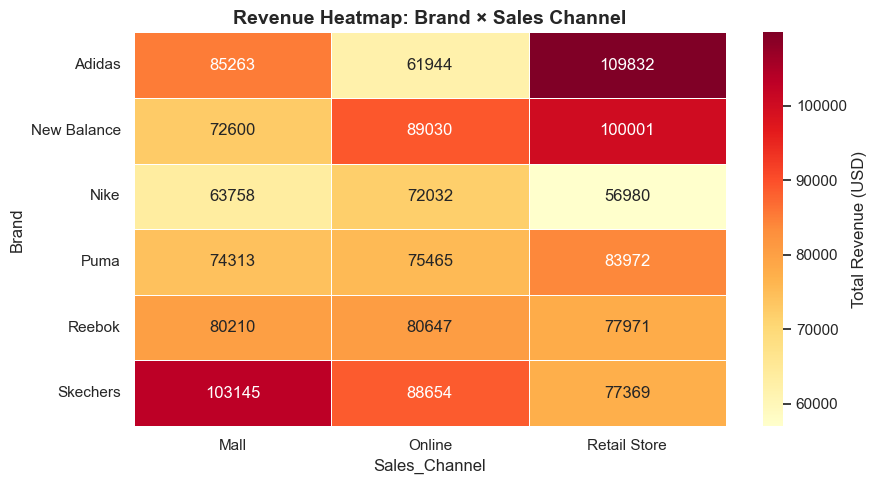

In [21]:
pivot = df.pivot_table(values='Revenue_USD', index='Brand',
                        columns='Sales_Channel', aggfunc='sum')

plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Total Revenue (USD)'})
plt.title('Revenue Heatmap: Brand × Sales Channel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

####  Observation

- The heatmap reveals **which brand–channel combinations** generate the most revenue.
- Darker cells (higher revenue) are relatively evenly distributed, suggesting **no single brand dominates a particular channel**.
- This indicates a healthy, diversified sales mix across brands and channels.

## 10. Correlation Analysis

We examine linear relationships between the numerical features using a correlation matrix and pair plots.

In [22]:
corr = df[num_cols].corr()
print('Correlation Matrix:')
print(corr.round(3))

Correlation Matrix:
             Price_USD  Units_Sold  Revenue_USD
Price_USD         1.00       -0.02         0.59
Units_Sold       -0.02        1.00         0.72
Revenue_USD       0.59        0.72         1.00


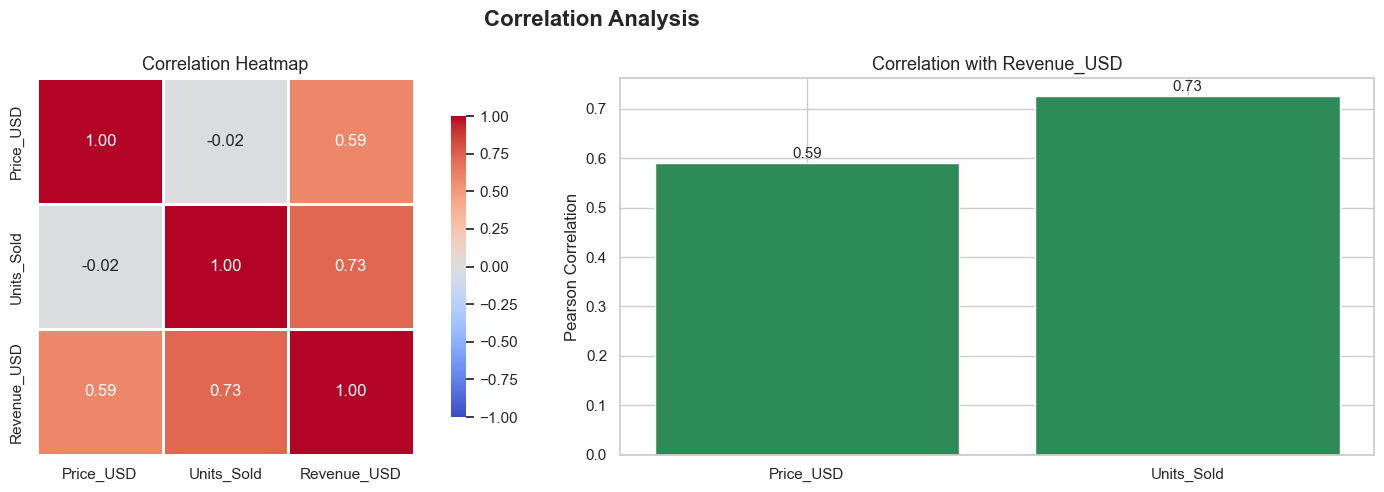

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Correlation Analysis', fontsize=16, fontweight='bold')

# Heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            square=True, linewidths=1, ax=axes[0],
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation Heatmap', fontsize=13)

# Bar chart of correlations with Revenue
rev_corr = corr['Revenue_USD'].drop('Revenue_USD')
colors = ['seagreen' if v > 0 else 'tomato' for v in rev_corr.values]
axes[1].bar(rev_corr.index, rev_corr.values, color=colors)
axes[1].set_title('Correlation with Revenue_USD', fontsize=13)
axes[1].set_ylabel('Pearson Correlation')
axes[1].axhline(0, color='black', linewidth=0.8)
for i, v in enumerate(rev_corr.values):
    axes[1].text(i, v + 0.01 if v > 0 else v - 0.03, f'{v:.2f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

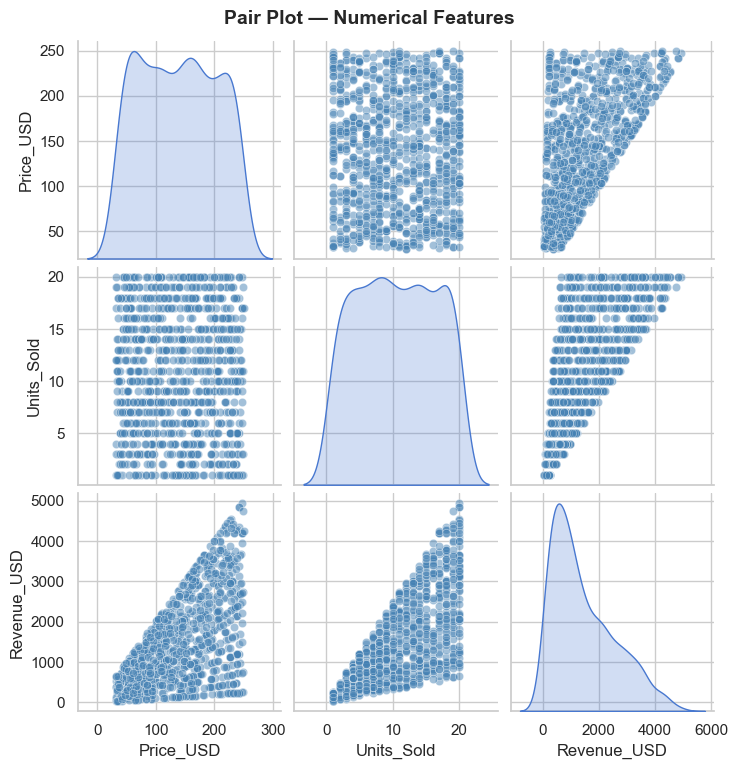

In [24]:
# Pair plot
g = sns.pairplot(df[num_cols], diag_kind='kde', plot_kws={'alpha': 0.5, 'color': 'steelblue'})
g.figure.suptitle('Pair Plot — Numerical Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()

###  Observation

| Feature Pair | Correlation | Interpretation |
|---|---|---|
| Units_Sold ↔ Revenue_USD | **+0.73** | Strong positive — more units sold → higher revenue |
| Price_USD ↔ Revenue_USD | **+0.59** | Moderate positive — higher price → higher revenue |
| Price_USD ↔ Units_Sold | **−0.02** | Near-zero — price has almost no effect on quantity sold |

**Key Takeaways:**
- Revenue is primarily driven by **quantity sold** (0.73), more than price (0.59).
- The near-zero correlation between Price and Units_Sold suggests **price elasticity is very low** — customers buy regardless of price point.
- This is a strong signal that increasing prices may not reduce sales volume significantly.

## 11. Time Series Analysis

We extract temporal features from the `Date` column to analyze how sales and revenue evolve over time.

In [25]:
# Extract time features
df['Month'] = df['Date'].dt.month_name()
df['Month_Num'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Quarter'] = df['Date'].dt.quarter
df['Day_of_Week'] = df['Date'].dt.day_name()

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

print('Date range:', df['Date'].min().date(), 'to', df['Date'].max().date())
print('Years covered:', df['Year'].unique())

Date range: 2025-01-03 to 2025-12-31
Years covered: [2025]


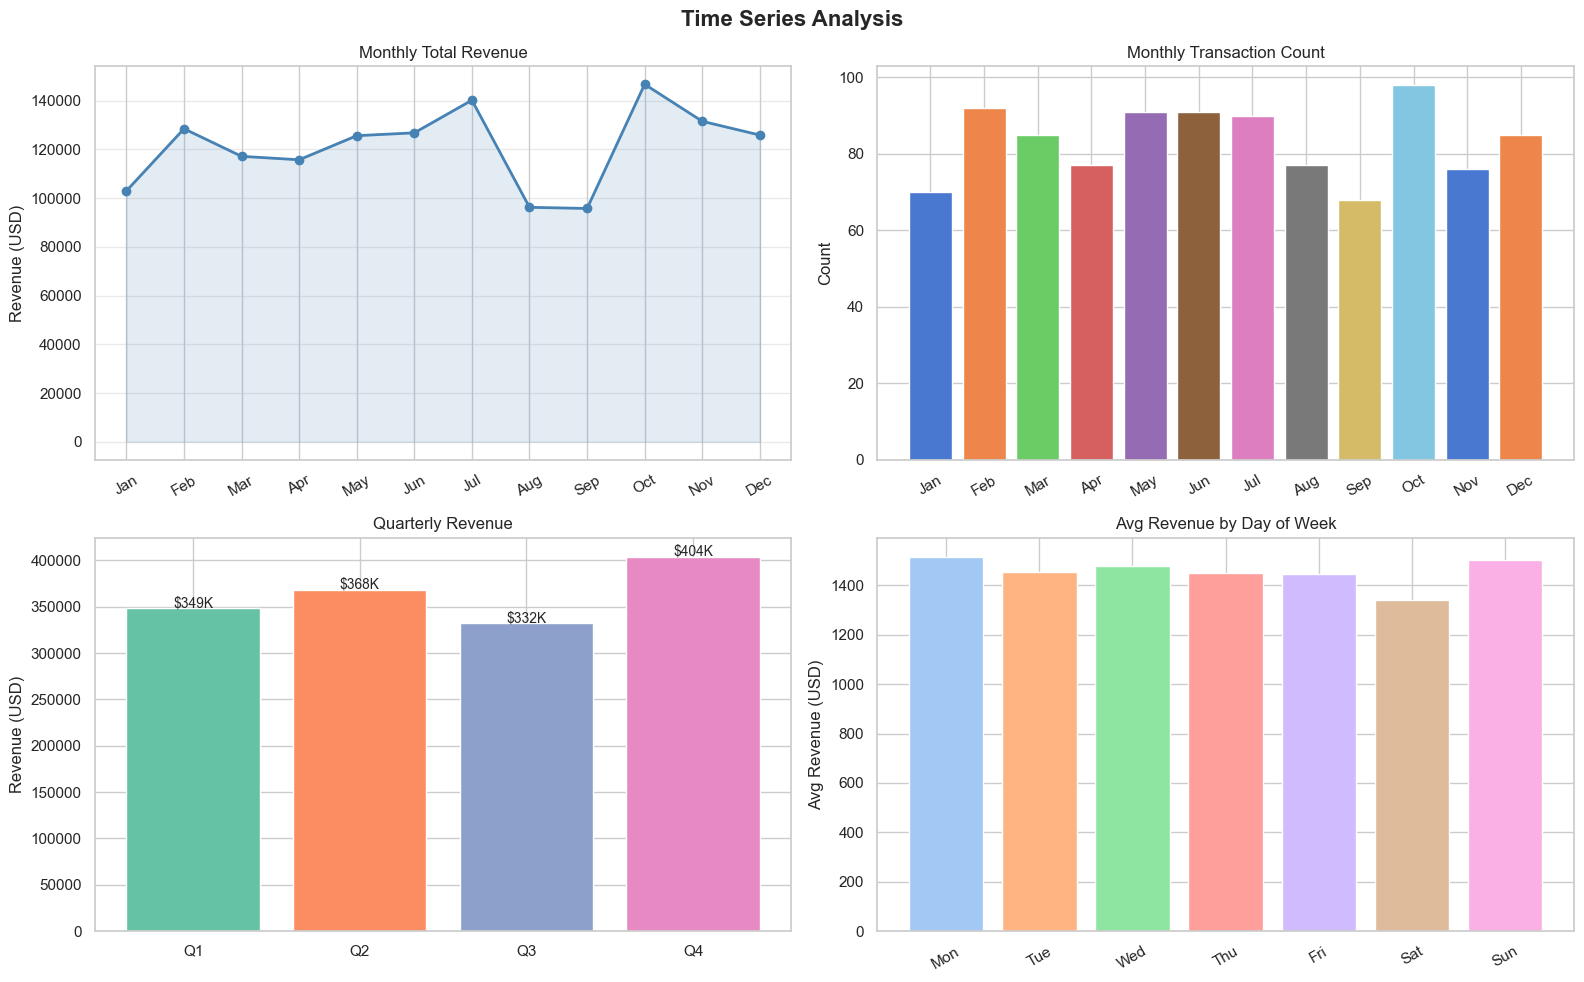

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Time Series Analysis', fontsize=16, fontweight='bold')

# Monthly Revenue
monthly_rev = df.groupby('Month')['Revenue_USD'].sum().reindex(month_order)
axes[0,0].plot(monthly_rev.index, monthly_rev.values, marker='o',
               color='steelblue', linewidth=2)
axes[0,0].fill_between(range(len(monthly_rev)), monthly_rev.values, alpha=0.15, color='steelblue')
axes[0,0].set_title('Monthly Total Revenue')
axes[0,0].set_ylabel('Revenue (USD)')
axes[0,0].set_xticks(range(len(monthly_rev)))
axes[0,0].set_xticklabels([m[:3] for m in month_order], rotation=30)
axes[0,0].grid(axis='y', alpha=0.4)

# Monthly Transaction Count
monthly_cnt = df.groupby('Month')['Sale_ID'].count().reindex(month_order)
axes[0,1].bar(range(len(monthly_cnt)), monthly_cnt.values,
              color=sns.color_palette('muted', 12))
axes[0,1].set_title('Monthly Transaction Count')
axes[0,1].set_ylabel('Count')
axes[0,1].set_xticks(range(len(monthly_cnt)))
axes[0,1].set_xticklabels([m[:3] for m in month_order], rotation=30)

# Quarterly Revenue
quarterly_rev = df.groupby('Quarter')['Revenue_USD'].sum()
axes[1,0].bar([f'Q{q}' for q in quarterly_rev.index], quarterly_rev.values,
              color=sns.color_palette('Set2', 4))
axes[1,0].set_title('Quarterly Revenue')
axes[1,0].set_ylabel('Revenue (USD)')
for i, v in enumerate(quarterly_rev.values):
    axes[1,0].text(i, v + 1000, f'${v/1000:.0f}K', ha='center', fontsize=10)

# Avg Revenue by Day of Week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_rev = df.groupby('Day_of_Week')['Revenue_USD'].mean().reindex(dow_order)
axes[1,1].bar(range(len(dow_rev)), dow_rev.values,
              color=sns.color_palette('pastel', 7))
axes[1,1].set_title('Avg Revenue by Day of Week')
axes[1,1].set_ylabel('Avg Revenue (USD)')
axes[1,1].set_xticks(range(7))
axes[1,1].set_xticklabels([d[:3] for d in dow_order], rotation=30)

plt.tight_layout()
plt.show()

###  Observation

- **Monthly Revenue:** Revenue fluctuates across months without a clear monotonic trend, suggesting relatively stable demand year-round.
- **Monthly Transactions:** Transaction counts per month are fairly balanced (~80–90 per month), indicating consistent sales activity.
- **Quarterly Revenue:** Revenue is distributed across quarters, allowing comparison of Q1–Q4 performance to identify seasonal peaks.
- **Day of Week:** Revenue patterns across weekdays can reveal whether weekends or weekdays drive higher sales.

## 12. Key Insights & Conclusions

A comprehensive summary of all findings from this Exploratory Data Analysis.

In [37]:
print('=' * 60)
print('        KEY INSIGHTS FROM EDA — SHOES SALES DATASET')
print('=' * 60)

top_brand     = df['Brand'].value_counts().idxmax()
top_rev_brand = df.groupby('Brand')['Revenue_USD'].sum().idxmax()
top_country   = df.groupby('Country')['Revenue_USD'].mean().idxmax()
top_channel   = df.groupby('Sales_Channel')['Revenue_USD'].mean().idxmax()
top_shoe      = df.groupby('Shoe_Type')['Revenue_USD'].sum().idxmax()

print(f'''
1. DATASET QUALITY
   - 1,000 records | 10 columns | No missing values | No duplicates
   - Dataset is clean and ready for modelling

2. TOP PERFORMERS
   - Most transactions:  {top_brand} ({df["Brand"].value_counts().max()} sales)
   - Highest revenue:    {top_rev_brand} (${df.groupby("Brand")["Revenue_USD"].sum().max():,.0f})
   - Best avg country:   {top_country} (${df.groupby("Country")["Revenue_USD"].mean().max():.0f} avg/txn)
   - Best channel:       {top_channel} (${df.groupby("Sales_Channel")["Revenue_USD"].mean().max():.0f} avg/txn)
   - Top shoe type:      {top_shoe} (${df.groupby("Shoe_Type")["Revenue_USD"].sum().max():,.0f} total)

3. PRICING & REVENUE
   - Avg price per unit: ${df["Price_USD"].mean():.2f}
   - Avg revenue/txn:    ${df["Revenue_USD"].mean():.2f}
   - Revenue range:      ${df["Revenue_USD"].min():.2f} – ${df["Revenue_USD"].max():.2f}
   - Revenue outliers:   4 transactions (0.4%) — retained as valid data

4. CORRELATIONS
   - Units Sold ↔ Revenue: +0.73 (strong — volume drives revenue)
   - Price     ↔ Revenue: +0.59 (moderate — price also contributes)
   - Price     ↔ Units:   −0.02 (negligible — low price elasticity)

5. CHANNEL STRATEGY
   - All 3 channels roughly equal — diversified and resilient
   - Retail Store marginally outperforms Online & Mall

6. RECOMMENDATIONS
   - Invest more in Skechers & New Balance partnerships
   - Focus marketing spend on UAE and USA markets
   - Promote Sneakers and Boots — highest revenue categories
   - Consider price increases (low elasticity = minimal volume impact)
   - Expand Retail Store presence — highest avg revenue channel
''')

        KEY INSIGHTS FROM EDA — SHOES SALES DATASET

1. DATASET QUALITY
   - 1,000 records | 10 columns | No missing values | No duplicates
   - Dataset is clean and ready for modelling

2. TOP PERFORMERS
   - Most transactions:  Skechers (196 sales)
   - Highest revenue:    Skechers ($269,169)
   - Best avg country:   UAE ($1557 avg/txn)
   - Best channel:       Retail Store ($1493 avg/txn)
   - Top shoe type:      Sneakers ($283,215 total)

3. PRICING & REVENUE
   - Avg price per unit: $137.86
   - Avg revenue/txn:    $1453.19
   - Revenue range:      $32.38 – $4938.40
   - Revenue outliers:   4 transactions (0.4%) — retained as valid data

4. CORRELATIONS
   - Units Sold ↔ Revenue: +0.73 (strong — volume drives revenue)
   - Price     ↔ Revenue: +0.59 (moderate — price also contributes)
   - Price     ↔ Units:   −0.02 (negligible — low price elasticity)

5. CHANNEL STRATEGY
   - All 3 channels roughly equal — diversified and resilient
   - Retail Store marginally outperforms Online 

---

##  Summary

This EDA successfully explored a **1,000-transaction global shoe sales dataset** across 10 features. The analysis covered

| Step | Outcome | 
|---|---|
| Data Loading & Inspection | 1,000 rows, 10 columns, well-structured | 
| Type Conversion | Date converted to datetime; categoricals typed correctly | 
| Missing Values | Zero nulls — no imputation needed | 
| Duplicates | Zero duplicates — data is unique per transaction | 
| Summary Stats | Revenue is right-skewed; Price is uniformly distributed | 
| Univariate Analysis | Balanced brand/shoe/country distribution; equal channel split |
| Outlier Detection | 4 outliers in Revenue (0.4%) — valid and retained | 
| Bivariate Analysis | Skechers & UAE lead; Retail Store edges others | 
| Correlation | Volume drives revenue more than price | 
| Time Series | Consistent monthly performance with quarterly variation | 


---
